In [2]:
import pandas as pd
import numpy as np

# -----------------------------
# Step 0: Data Loading & Pre-processing
# -----------------------------

# Path to the Excel file (adjust if needed)
file_path = "online_retail_II.xlsx"

# Load all sheets into a dict of DataFrames, then concatenate
# Business logic: Online Retail II comes in 2 sheets (e.g., 2009-2010 and 2010-2011),
# which together represent the full transaction history.
sheets_dict = pd.read_excel(file_path, sheet_name=None)
df = pd.concat(sheets_dict.values(), ignore_index=True)

# Ensure we work on a copy for safety
df = df.copy()

# Drop rows with missing Customer ID (mandatory for customer-centric analysis)
df = df.dropna(subset=["Customer ID"])

# Convert InvoiceDate to datetime (coerce errors to NaT, which can later be ignored in recency)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Convert Customer ID to integer, then to string (avoid 12345.0 style floats)
# Int64 (nullable integer) allows for potential missing values, though we've already dropped NaNs.
df["Customer ID"] = df["Customer ID"].astype("Int64").astype(str)

# Ensure Invoice and StockCode are strings
df["Invoice"] = df["Invoice"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)

# Create is_canceled flag: True if invoice starts with 'C', else False
# Business logic: In this dataset, 'C' prefix generally denotes credit/cancellation invoices.
df["is_canceled"] = df["Invoice"].str.startswith("C", na=False)

# Remove rows with non-positive prices (zero or negative are anomalies)
df = df[df["Price"] > 0]

# Enforce quantity sign rules:
# - Non-canceled orders: Quantity must be positive (actual purchases)
# - Canceled orders: Quantity must be negative (returns/credits)
mask_valid_quantity = (
    (~df["is_canceled"] & (df["Quantity"] > 0))
    | (df["is_canceled"] & (df["Quantity"] < 0))
)
df = df[mask_valid_quantity]

# Remove non-product transactions:
# - StockCode is strictly alphabetical (likely codes for charges/adjustments)
# - OR StockCode corresponds to known manual/postage/fees (business logic)
non_product_codes = {
    "POST",
    "D",
    "M",
    "CRUK",
    "BANK CHARGES",
}

stockcode_upper = df["StockCode"].str.upper()

mask_strict_alpha = stockcode_upper.str.fullmatch(r"[A-Z]+", na=False)
mask_manual_codes = stockcode_upper.isin(non_product_codes)

# Keep only true product rows
df = df[~(mask_strict_alpha | mask_manual_codes)]

# Fill missing values in categorical (object) columns with "Unknown"
# Business logic: For segmentation, it is better to keep customers with
# unknown attributes than to drop them entirely.
categorical_cols = df.select_dtypes(include=["object"]).columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

# Compute LineTotal for all rows (cancellations will have negative totals)
df["LineTotal"] = df["Quantity"] * df["Price"]

# -----------------------------
# Step 1: Customer-Centric Feature Engineering
# -----------------------------

# Reference date for recency: the latest invoice date in the dataset
# Business logic: recency is measured as "days since last purchase"
ref_date = df["InvoiceDate"].max()

# Base index: all unique customers (as strings)
customer_index = pd.Index(sorted(df["Customer ID"].unique()), name="Customer ID")
customer_df = pd.DataFrame(index=customer_index)

# 1) Frequency: count of unique non-canceled invoices per customer
# Business logic: measures how many separate purchase occasions the customer had.
freq = (
    df[~df["is_canceled"]]
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .rename("Frequency")
)
customer_df["Frequency"] = freq.reindex(customer_df.index, fill_value=0)

# 2) Monetary: total spending (sum of LineTotal across all rows, including cancellations)
# Business logic: cancellations reduce the net monetary value by offsetting prior spend.
monetary = (
    df.groupby("Customer ID")["LineTotal"]
    .sum()
    .rename("Monetary")
)
customer_df["Monetary"] = monetary.reindex(customer_df.index, fill_value=0.0)

# 3) Recency: days since last purchase (using all invoices, canceled or not, as "activity")
# If you prefer only successful purchases, filter with ~df["is_canceled"] here.
last_purchase = (
    df.groupby("Customer ID")["InvoiceDate"]
    .max()
)
recency = (ref_date - last_purchase).dt.days.rename("Recency")
customer_df["Recency"] = recency.reindex(customer_df.index)

# 4) Variety: number of unique products (StockCode) purchased, excluding canceled invoices
# Business logic: measures breadth of product engagement.
variety = (
    df[~df["is_canceled"]]
    .groupby("Customer ID")["StockCode"]
    .nunique()
    .rename("Variety")
)
customer_df["Variety"] = variety.reindex(customer_df.index, fill_value=0)

# 5) Average Basket Size: average total quantity per non-canceled invoice
# Business logic: captures how big the customer's typical order is.
non_canceled = df[~df["is_canceled"]].copy()

# Sum quantity per (Customer, Invoice) to get basket size per invoice
basket_sizes = (
    non_canceled
    .groupby(["Customer ID", "Invoice"])["Quantity"]
    .sum()
)

avg_basket_size = (
    basket_sizes
    .groupby("Customer ID")
    .mean()
    .rename("AvgBasketSize")
)
customer_df["AvgBasketSize"] = avg_basket_size.reindex(customer_df.index, fill_value=0.0)

# 6) Cancellation Rate: (# canceled invoices) / (total # invoices)
# Business logic: measures reliability/return behavior of the customer.
canceled_invoices = (
    df[df["is_canceled"]]
    .groupby("Customer ID")["Invoice"]
    .nunique()
)

total_invoices = (
    df.groupby("Customer ID")["Invoice"]
    .nunique()
)

cancellation_rate = (
    canceled_invoices
    .div(total_invoices)
    .fillna(0.0)
    .rename("CancellationRate")
)
customer_df["CancellationRate"] = cancellation_rate.reindex(customer_df.index, fill_value=0.0)

# Reset index so Customer ID becomes a column
customer_df = customer_df.reset_index()

# -----------------------------
# Outputs
# -----------------------------

print("customer_df.info():")
print(customer_df.info())
print("\ncustomer_df.head():")
print(customer_df.head())
print("\ncustomer_df.describe(include='all'):")
print(customer_df.describe(include="all"))

customer_df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5876 entries, 0 to 5875
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer ID       5876 non-null   object 
 1   Frequency         5876 non-null   int64  
 2   Monetary          5876 non-null   float64
 3   Recency           5876 non-null   int64  
 4   Variety           5876 non-null   int64  
 5   AvgBasketSize     5876 non-null   float64
 6   CancellationRate  5876 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 321.5+ KB
None

customer_df.head():
  Customer ID  Frequency  Monetary  Recency  Variety  AvgBasketSize  \
0       12346         12    368.36      325       27    6190.416667   
1       12347          8   5633.32        1      126     410.750000   
2       12348          5   1658.40       74       24     540.800000   
3       12349          3   3654.54       18      137     540.333333   
4     

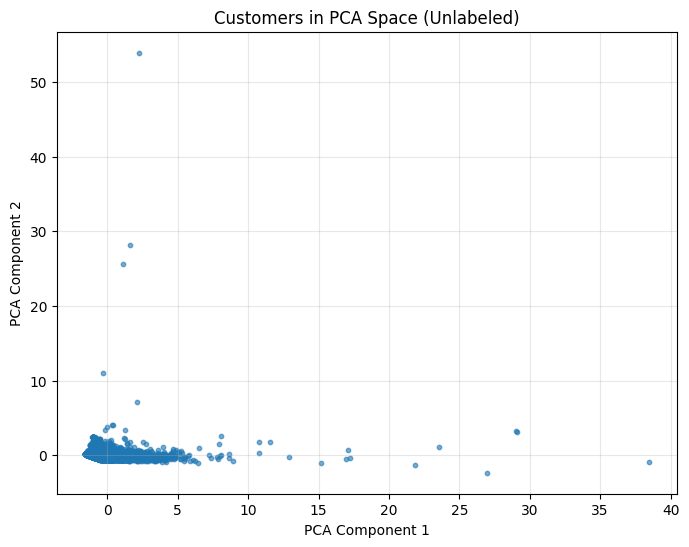

================ Model Selection Summary ================
Winning algorithm: DBSCAN
Best silhouette score: 0.7736
Optimal parameters: {'eps': 2.5, 'min_samples': 5}
Number of clusters (excluding noise for DBSCAN): 2


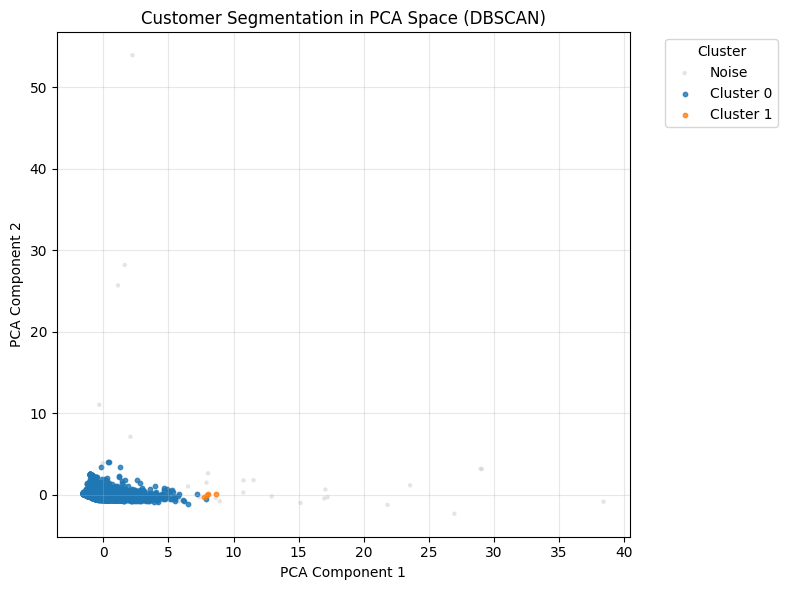

In [3]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# -----------------------------
# Step 2: Customer Segmentation & Visualization
# -----------------------------

# 1. Data Scaling
# Business logic: Features have very different scales (e.g., Monetary vs. Frequency),
# so we standardize to give each feature equal importance in distance-based models.
feature_cols = [
    "Frequency",
    "Monetary",
    "Recency",
    "Variety",
    "AvgBasketSize",
    "CancellationRate",
]

X = customer_df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Dimensionality Reduction (PCA to 2D)
# Business logic: PCA helps visualize structure/outliers and can slightly denoise features.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Optional: store PCA coordinates for inspection
customer_df["PCA1"] = X_pca[:, 0]
customer_df["PCA2"] = X_pca[:, 1]

# Basic scatter plot of PCA components (before clustering)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.6)
plt.title("Customers in PCA Space (Unlabeled)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True, alpha=0.3)
plt.show()

# 3. Clustering Algorithm 1: K-Means with dynamic K (2 to 10)
# Business logic: Try multiple K values and use silhouette score to choose the most
# well-separated structure.

best_k = None
best_kmeans_score = -1
best_kmeans_labels = None

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)

    # Silhouette score uses Euclidean distance by default
    score = silhouette_score(X_scaled, labels)

    if score > best_kmeans_score:
        best_kmeans_score = score
        best_k = k
        best_kmeans_labels = labels

# 4. Clustering Algorithm 2: DBSCAN with small parameter grid
# Business logic: DBSCAN can discover arbitrary-shaped clusters and treat noise explicitly.

eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 15, 20]

best_dbscan_score = -1
best_dbscan_params = None
best_dbscan_labels = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        # Exclude noise label -1 for cluster count and silhouette
        unique_labels = set(labels)
        non_noise_labels = {lab for lab in unique_labels if lab != -1}

        # Need at least 2 clusters (excluding noise) for a valid silhouette score
        if len(non_noise_labels) < 2:
            score = -1
        else:
            # Compute silhouette score on all points (including noise labels)
            # This is acceptable as long as at least 2 clusters exist.
            try:
                score = silhouette_score(X_scaled, labels)
            except ValueError:
                score = -1

        if score > best_dbscan_score:
            best_dbscan_score = score
            best_dbscan_params = {"eps": eps, "min_samples": min_samples}
            best_dbscan_labels = labels

# 5. Model Selection & Final Visualization

# Decide which algorithm wins based on best silhouette scores
if best_dbscan_score > best_kmeans_score:
    winning_algo = "DBSCAN"
    winning_score = best_dbscan_score
    winning_labels = best_dbscan_labels
    winning_params = best_dbscan_params

    # Number of clusters (excluding noise -1)
    unique_labels = set(winning_labels)
    n_clusters = len([lab for lab in unique_labels if lab != -1])
else:
    winning_algo = "KMeans"
    winning_score = best_kmeans_score
    winning_labels = best_kmeans_labels
    winning_params = {"n_clusters": best_k}

    # Number of clusters is best_k
    n_clusters = best_k

# Attach chosen cluster labels to customer_df
customer_df["Cluster"] = winning_labels

# Print a formatted summary
print("================ Model Selection Summary ================")
print(f"Winning algorithm: {winning_algo}")
print(f"Best silhouette score: {winning_score:.4f}")
print(f"Optimal parameters: {winning_params}")
print(f"Number of clusters (excluding noise for DBSCAN): {n_clusters}")
print("=========================================================")

# Final visualization: PCA scatter colored by final clusters
plt.figure(figsize=(8, 6))

# Use a colormap that can handle noise label -1 and cluster IDs
unique_clusters = np.unique(winning_labels)

for cluster_id in unique_clusters:
    mask = winning_labels == cluster_id
    if cluster_id == -1:
        label = "Noise" if winning_algo == "DBSCAN" else "Cluster -1"
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=10,
            alpha=0.6,
            label=label,
            c="lightgray",
            edgecolors="none",
        )
    else:
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=10,
            alpha=0.8,
            label=f"Cluster {cluster_id}",
        )

plt.title(f"Customer Segmentation in PCA Space ({winning_algo})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Cluster Profile Summary ===
         Frequency_mean  Frequency_median  Monetary_mean  Monetary_median  \
Cluster                                                                     
 0                 5.68               3.0        2205.34           849.48   
-1               105.75              99.0      125587.75         66674.00   
 1               109.50             108.0       80954.61         86373.10   

         Recency_mean  Recency_median  Variety_mean  Variety_median  \
Cluster                                                               
 0             199.21            94.0         78.76            44.0   
-1              83.75             3.0        720.21           550.5   
 1               9.75             0.5        150.00           112.0   

         AvgBasketSize_mean  AvgBasketSize_median  CancellationRate_mean  \
Cluster                                                                    
 0                   215.90                157.75                   0.11  

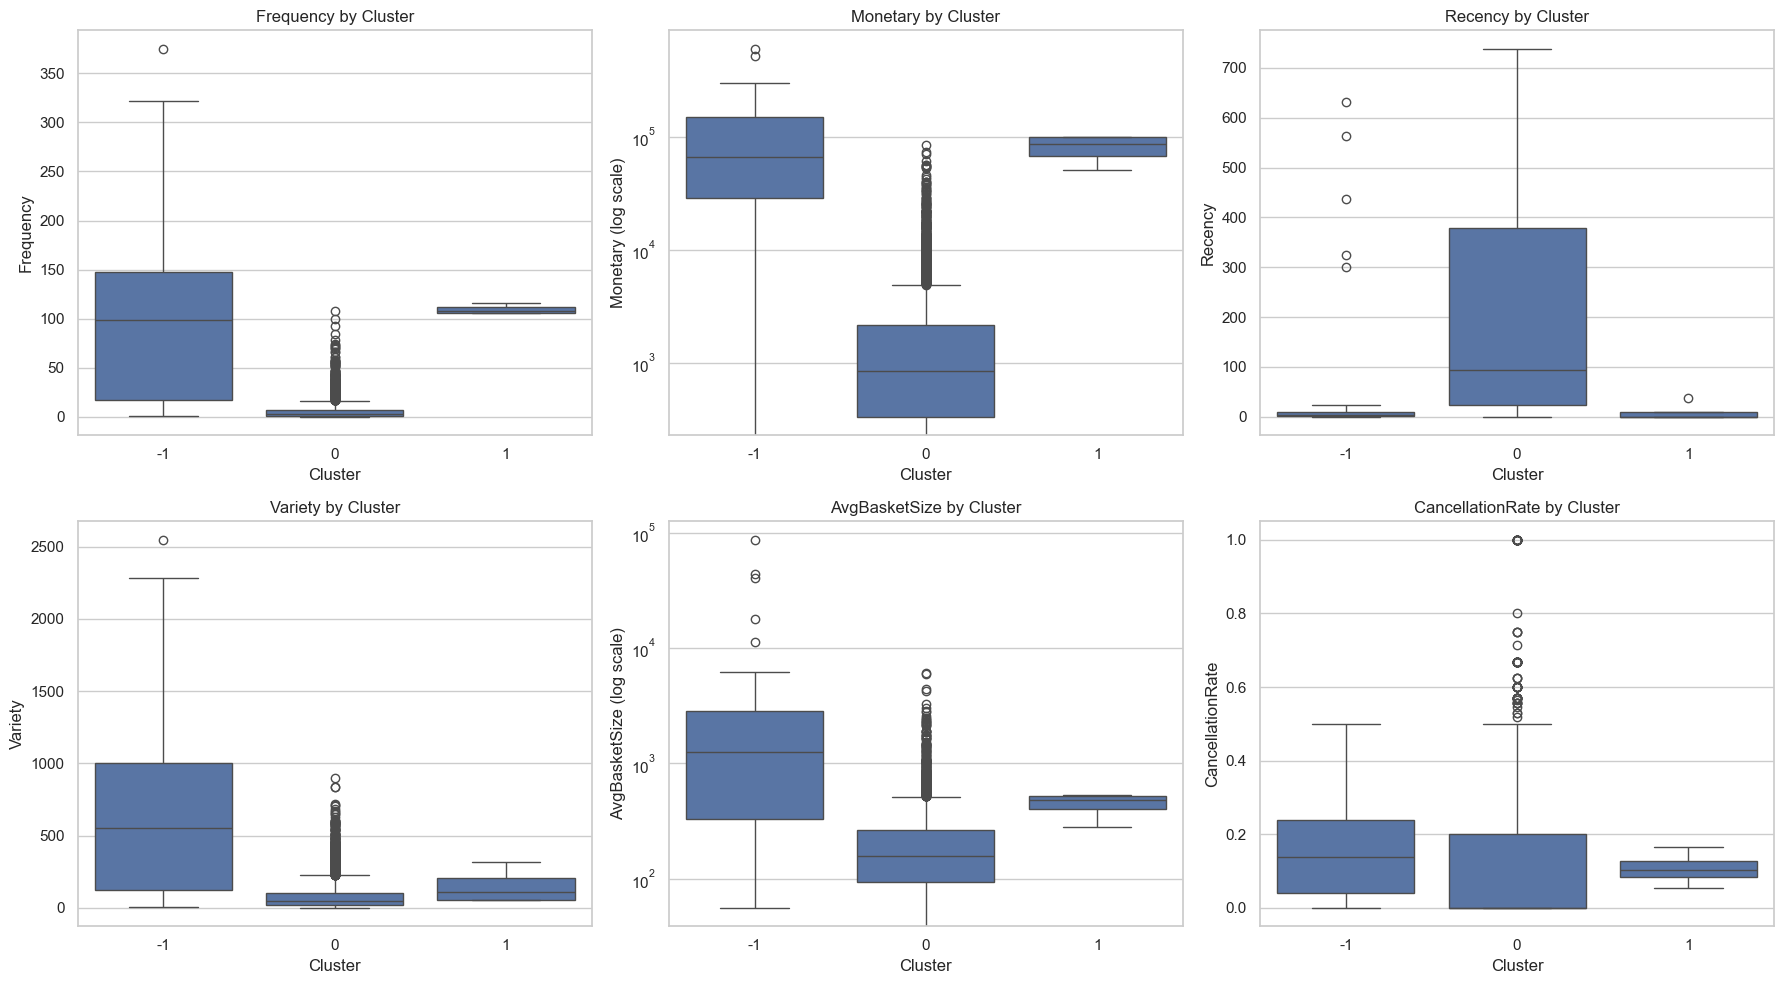


=== Top 3 Insights ===
1. Cluster 0 has lower average Monetary (2205.34) than Cluster 1 (80954.61).
2. Cluster 0 has lower average AvgBasketSize (215.90) than Cluster 1 (443.18).
3. Noise cluster (-1) has higher average Monetary value (125587.75) compared to the overall customer mean (2846.88).


In [10]:
import seaborn as sns

# -----------------------------
# Step 2c: Deep Cluster Profiling for Business Insight
# -----------------------------

# 1. Detailed Statistics
# Business logic: Summarize how each segment behaves across key RFM-like
# features and how economically important each segment is.

profile_features = [
    "Frequency",
    "Monetary",
    "Recency",
    "Variety",
    "AvgBasketSize",
    "CancellationRate",
]

# Aggregate mean and median for each feature
agg_dict = {feat: ["mean", "median"] for feat in profile_features}
cluster_stats = customer_df.groupby("Cluster").agg(agg_dict)

# Flatten MultiIndex columns (Feature_stat)
cluster_stats.columns = [
    f"{feat}_{stat}" for feat, stat in cluster_stats.columns
]

# Add count of customers per cluster
cluster_stats["CustomerCount"] = customer_df.groupby("Cluster").size()

# Percentage of total customers
total_customers = len(customer_df)
cluster_stats["CustomerPct"] = (
    cluster_stats["CustomerCount"] / total_customers * 100
)

# Total monetary sum per cluster and its share of total revenue
cluster_stats["MonetaryTotal"] = customer_df.groupby("Cluster")["Monetary"].sum()

total_revenue = customer_df["Monetary"].sum()
cluster_stats["RevenuePct"] = (
    np.where(
        total_revenue != 0,
        cluster_stats["MonetaryTotal"] / total_revenue * 100,
        0,
    )
)

# Sort clusters by RevenuePct descending for easier business reading
cluster_profile = cluster_stats.sort_values("RevenuePct", ascending=False)

print("=== Cluster Profile Summary ===")
print(cluster_profile.round(2))

# 2. Distribution Visualization: Boxplots per feature across clusters

sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feat in enumerate(profile_features):
    ax = axes[idx]
    sns.boxplot(
        x="Cluster",
        y=feat,
        data=customer_df,
        ax=ax,
        showfliers=True,
    )
    ax.set_title(f"{feat} by Cluster")

    # Use log scale for features that typically have heavy tails
    if feat in ["Monetary", "AvgBasketSize"]:
        # Only apply log scale if there are positive values
        if (customer_df[feat] > 0).any():
            ax.set_yscale("log")
            ax.set_ylabel(f"{feat} (log scale)")

plt.tight_layout()
plt.show()

# 3. Top 3 insights (dynamic, revenue-driven, noise-aware)

insights = []

# Helper to fetch mean safely
def get_cluster_mean(cluster_id, feature):
    col = f"{feature}_mean"
    if cluster_id in cluster_profile.index and col in cluster_profile.columns:
        return cluster_profile.loc[cluster_id, col]
    return None

# Separate noise (if present) from normal clusters
noise_label = -1
normal_clusters = [c for c in cluster_profile.index if c != noise_label]

# Overall means for context
overall_means = customer_df[profile_features].mean()

# 3.1: Revenue dominance insight (top normal cluster)
if normal_clusters:
    top_cluster = normal_clusters[0]
    top_rev_pct = cluster_profile.loc[top_cluster, "RevenuePct"]
    cust_pct = cluster_profile.loc[top_cluster, "CustomerPct"]
    insights.append(
        f"Cluster {top_cluster} contributes about {top_rev_pct:.1f}% of revenue "
        f"from {cust_pct:.1f}% of customers, making it a key revenue segment."
    )

# 3.2: Largest contrast between top two normal clusters (if at least 2)
if len(normal_clusters) >= 2:
    c1, c2 = normal_clusters[0], normal_clusters[1]
    diffs = []
    for feat in profile_features:
        m1 = get_cluster_mean(c1, feat)
        m2 = get_cluster_mean(c2, feat)
        if m1 is not None and m2 is not None:
            diffs.append((feat, m1, m2, abs(m1 - m2)))

    if diffs:
        # Sort features by absolute mean difference
        diffs_sorted = sorted(diffs, key=lambda x: x[3], reverse=True)
        # Take up to two strongest differences as insights
        for feat, m1, m2, _ in diffs_sorted[:2]:
            direction = "higher" if m1 > m2 else "lower"
            insights.append(
                f"Cluster {c1} has {direction} average {feat} ({m1:.2f}) than Cluster {c2} ({m2:.2f})."
            )
            if len(insights) >= 3:
                break

# 3.3: Noise cluster behavior (if present and we still have room for insights)
if noise_label in cluster_profile.index and len(insights) < 3:
    noise_monetary = get_cluster_mean(noise_label, "Monetary")
    noise_cancel = get_cluster_mean(noise_label, "CancellationRate")

    if noise_monetary is not None and len(insights) < 3:
        direction = "lower" if noise_monetary < overall_means["Monetary"] else "higher"
        insights.append(
            f"Noise cluster (-1) has {direction} average Monetary value ({noise_monetary:.2f}) "
            f"compared to the overall customer mean ({overall_means['Monetary']:.2f})."
        )

    if noise_cancel is not None and len(insights) < 3:
        direction = "higher" if noise_cancel > overall_means["CancellationRate"] else "lower"
        insights.append(
            f"Noise cluster (-1) shows {direction} CancellationRate ({noise_cancel:.3f}) "
            f"compared to the overall mean ({overall_means['CancellationRate']:.3f})."
        )

# Ensure we output at most 3 insights
insights = insights[:3]

print("\n=== Top 3 Insights ===")
for i, txt in enumerate(insights, start=1):
    print(f"{i}. {txt}")


=== Median AvgDaysBetweenPurchases by Cluster ===
Cluster
-1      7.68
 0    246.00
 1      6.84
Name: AvgDaysBetweenPurchases, dtype: float64

=== Segment-Specific Market Basket Analysis (FP-Growth) ===

Cluster -1: 3492 invoices. Running FP-Growth...
Cluster -1: Top 3 rules (using min_support=0.02):
  Rule: {22698} -> {22697, 22699} | Lift=28.110
  Rule: {22697, 22699} -> {22698} | Lift=28.110
  Rule: {22697} -> {22698, 22699} | Lift=27.520

Cluster 0: 39920 invoices. Running FP-Growth...
Cluster 0: Top 3 rules (using min_support=0.02):
  Rule: {82482} -> {82494L} | Lift=14.989
  Rule: {82494L} -> {82482} | Lift=14.989
  Rule: {22469} -> {22470} | Lift=11.874

Cluster 1: 491 invoices. Running FP-Growth...
Cluster 1: Top 3 rules (using min_support=0.02):
  Rule: {21914} -> {21915} | Lift=27.697
  Rule: {21915} -> {21914} | Lift=27.697
  Rule: {85099F} -> {22386} | Lift=15.431

=== Time Series Analysis for Best Cluster's Top Item ===
Best cluster (by customer count): 0 with 5844 custom

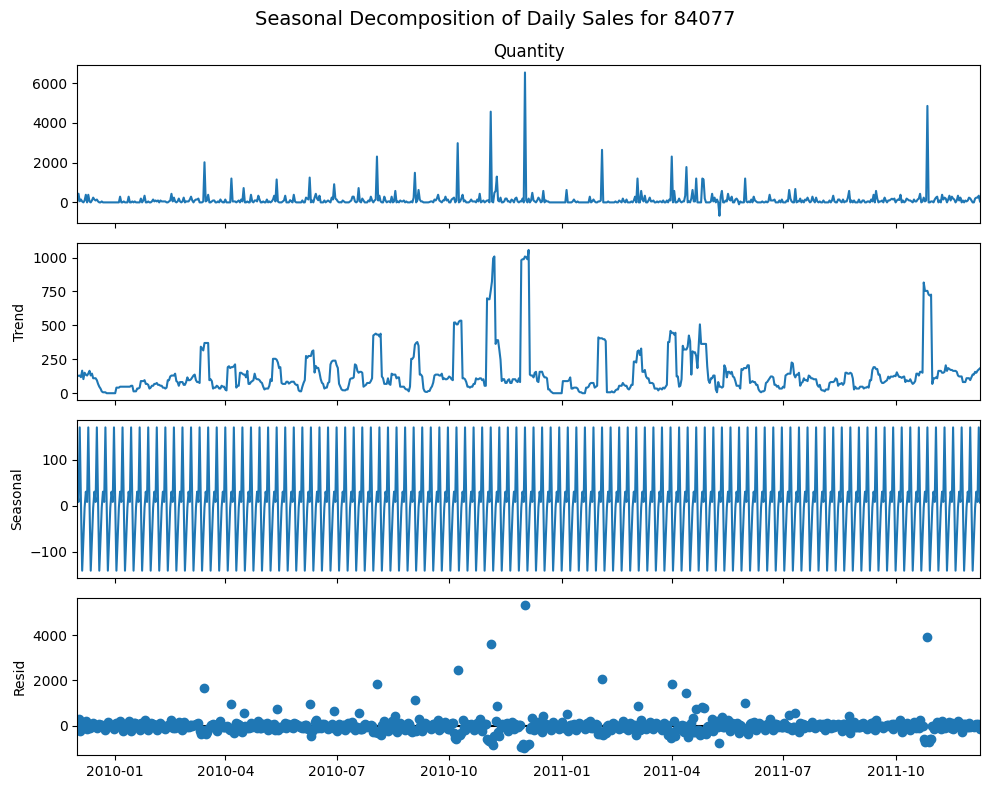


The code identified the largest customer segment (by number of customers), then selected its single most popular item (84077 - WORLD WAR 2 GLIDERS ASSTD DESIGNS). For that item within the chosen segment, it built a daily time series of quantities sold, filled missing dates with zero sales, and applied a seasonal decomposition with weekly seasonality (period=7) to separate the observed series into trend, seasonal, and residual components.


In [4]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
from statsmodels.tsa.seasonal import seasonal_decompose

# -----------------------------
# Step 3: Segment-Specific Market Basket Analysis & Time Series
# -----------------------------

# 3a. Cluster Deep-Dive: AvgDaysBetweenPurchases

# Approximate average days between purchases:
# total dataset timespan (days) / customer's purchase frequency.
min_date = df["InvoiceDate"].min()
max_date = df["InvoiceDate"].max()

total_days = (max_date - min_date).days

# Avoid division by zero: if Frequency == 0, set as NaN
customer_df["AvgDaysBetweenPurchases"] = np.where(
    customer_df["Frequency"] > 0,
    total_days / customer_df["Frequency"],
    np.nan,
)

median_days_by_cluster = (
    customer_df
    .groupby("Cluster")["AvgDaysBetweenPurchases"]
    .median()
    .sort_index()
)

print("=== Median AvgDaysBetweenPurchases by Cluster ===")
print(median_days_by_cluster.round(2))

# 3b. Segment-Specific Market Basket Analysis (FP-Growth)

# Merge cluster labels back to the cleaned transactional data
# (Customer-level cluster assigned earlier in the pipeline)
df_with_cluster = df.merge(
    customer_df[["Customer ID", "Cluster"]],
    on="Customer ID",
    how="left",
)

unique_clusters = sorted(df_with_cluster["Cluster"].dropna().unique())

print("\n=== Segment-Specific Market Basket Analysis (FP-Growth) ===")

# Minimum number of invoices in a cluster to perform MBA
min_invoices_mba = 25

# Dynamic min_support search: try these levels in order per cluster
support_levels = [0.05, 0.02, 0.01, 0.005]

for cluster_id in unique_clusters:
    cluster_tx = df_with_cluster[df_with_cluster["Cluster"] == cluster_id]

    # Use unique invoices count as cluster size proxy
    n_invoices = cluster_tx["Invoice"].nunique()

    if n_invoices < min_invoices_mba:
        print(f"\nCluster {cluster_id}: Skipping MBA (only {n_invoices} invoices).")
        continue

    print(f"\nCluster {cluster_id}: {n_invoices} invoices. Running FP-Growth...")

    # Build basket: rows = invoices, columns = StockCodes, values = 1 if purchased
    basket = (
        cluster_tx
        .groupby(["Invoice", "StockCode"])['Quantity']
        .sum()
        .unstack()
        .fillna(0)
    )

    # Convert to strict boolean presence/absence matrix (required by mlxtend)
    basket_bool = basket.gt(0)

    rules_found = False

    # Dynamic min_support: stop at first level that yields at least 1 rule
    for s in support_levels:
        frequent_itemsets = fpgrowth(basket_bool, min_support=s, use_colnames=True)

        if frequent_itemsets.empty:
            continue

        # Generate association rules using lift
        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

        if rules.empty:
            continue

        rules_sorted = rules.sort_values("lift", ascending=False).head(3)

        print(f"Cluster {cluster_id}: Top 3 rules (using min_support={s}):")
        for idx, row in rules_sorted.iterrows():
            antecedents = ', '.join(sorted(map(str, row['antecedents'])))
            consequents = ', '.join(sorted(map(str, row['consequents'])))
            print(
                f"  Rule: {{{antecedents}}} -> {{{consequents}}} | "
                f"Lift={row['lift']:.3f}"
            )

        rules_found = True
        break

    if not rules_found:
        print(
            f"Cluster {cluster_id}: No association rules found even at the lowest "
            f"min_support={support_levels[-1]}"
        )

# 3c. Time Series Analysis & Decomposition

print("\n=== Time Series Analysis for Best Cluster's Top Item ===")

# Identify the 'best' cluster as the one with the largest number of customers
cluster_counts = customer_df["Cluster"].value_counts()
if cluster_counts.empty:
    print("No clusters available for time series analysis.")
else:
    best_cluster = cluster_counts.idxmax()
    n_customers_best = cluster_counts.max()

    print(f"Best cluster (by customer count): {best_cluster} with {n_customers_best} customers.")

    # Filter transactions for this cluster
    best_cluster_tx = df_with_cluster[df_with_cluster["Cluster"] == best_cluster]

    if best_cluster_tx.empty:
        print("No transactions found for the best cluster; skipping time series analysis.")
    else:
        # Identify most popular item (by total Quantity)
        item_qty = (
            best_cluster_tx
            .groupby("StockCode")["Quantity"]
            .sum()
            .sort_values(ascending=False)
        )

        top_item_stockcode = item_qty.index[0]

        # Try to get a representative description (most common description for that stock code)
        desc_mode = (
            best_cluster_tx[best_cluster_tx["StockCode"] == top_item_stockcode]
            ["Description"]
            .mode()
        )
        top_item_description = desc_mode.iloc[0] if not desc_mode.empty else "Unknown description"

        print(f"Most popular item in cluster {best_cluster}: {top_item_stockcode} - {top_item_description}")

        # Build daily time series of quantity sold for this item
        item_tx = best_cluster_tx[best_cluster_tx["StockCode"] == top_item_stockcode].copy()
        item_tx["InvoiceDate"] = pd.to_datetime(item_tx["InvoiceDate"])

        daily_series = (
            item_tx
            .set_index("InvoiceDate")
            .resample("D")["Quantity"]
            .sum()
        )

        # Fill missing dates with 0
        daily_series = daily_series.asfreq("D", fill_value=0)

        # Seasonal decomposition with weekly seasonality (period=7)
        result = seasonal_decompose(daily_series, model="additive", period=7, extrapolate_trend="freq")

        # Plot decomposition
        fig = result.plot()
        fig.set_size_inches(10, 8)
        fig.suptitle(
            f"Seasonal Decomposition of Daily Sales for {top_item_stockcode}",
            fontsize=14,
        )
        plt.tight_layout()
        plt.show()

        print(
            "\nThe code identified the largest customer segment (by number of customers), "
            f"then selected its single most popular item ({top_item_stockcode} - {top_item_description}). "
            "For that item within the chosen segment, it built a daily time series of quantities sold, "
            "filled missing dates with zero sales, and applied a seasonal decomposition with weekly "
            "seasonality (period=7) to separate the observed series into trend, seasonal, and residual components."
        )


In [5]:
from sklearn.neighbors import LocalOutlierFactor

# -----------------------------
# Step 4: Anomaly Detection with LOF
# -----------------------------

# 1. Run LOF on scaled customer features
# Using the same X_scaled from Step 2 (StandardScaler output on the 6 features).
# n_neighbors=20 evaluates local density around each point.
lof = LocalOutlierFactor(n_neighbors=20, metric="euclidean")
lof_labels = lof.fit_predict(X_scaled)
lof_scores = lof.negative_outlier_factor_

# Add LOF scores to customer_df (more negative = more anomalous)
customer_df["LOF_Score"] = lof_scores

# 2. Extract Top 10 Anomalies
# Sort by LOF_Score ascending (most negative first)
customer_df_sorted = customer_df.sort_values("LOF_Score", ascending=True)

# Take the top 10 most anomalous customers
top_10_anomalies = customer_df_sorted.head(10).copy()

print("=== Top 10 Anomalous Customers (by LOF) ===")
print(
    top_10_anomalies[
        [
            "Customer ID",
            "LOF_Score",
            "Frequency",
            "Monetary",
            "Recency",
            "Variety",
            "AvgBasketSize",
            "CancellationRate",
            "Cluster",
        ]
    ].round({"LOF_Score": 4, "Monetary": 2, "AvgBasketSize": 2, "CancellationRate": 3})
)

# 3. Analyze the Anomalies: Why were they flagged?

print("\n=== Qualitative Explanations for Top 10 Anomalies ===")

for _, row in top_10_anomalies.iterrows():
    cid = row["Customer ID"]
    cid_tx = df[df["Customer ID"] == cid]

    if cid_tx.empty:
        print(f"Customer {cid}: No transactions found in the cleaned dataset.")
        continue

    # Basic transactional stats per anomalous customer
    total_invoices = cid_tx["Invoice"].nunique()
    canceled_invoices = cid_tx[cid_tx["is_canceled"]]["Invoice"].nunique()
    max_quantity = cid_tx["Quantity"].max()
    min_quantity = cid_tx["Quantity"].min()
    net_spend = cid_tx["LineTotal"].sum()

    cancel_rate = (
        canceled_invoices / total_invoices if total_invoices > 0 else 0.0
    )

    print(
        f"Customer {cid}: {total_invoices} invoices, "
        f"{canceled_invoices} canceled (cancel rate {cancel_rate:.1%}), "
        f"max single-row quantity {max_quantity}, min quantity {min_quantity}, "
        f"net Monetary (LineTotal sum) {net_spend:.2f}."
    )


=== Top 10 Anomalous Customers (by LOF) ===
     Customer ID  LOF_Score  Frequency   Monetary  Recency  Variety  \
1318       13687   -25.4531          1   11880.84      437       45   
1532       13902   -14.0485          5   30375.26      631       57   
4051       16446   -13.8555          2      -6.10        0        3   
5640       18052    -7.4800          1   10877.18      564       16   
5690       18102    -4.9290        145  606243.25        0      382   
2269       14646    -4.2811        145  523202.74        1      960   
1904       14277    -4.1893          8    3988.02       14      332   
5432       17841    -3.8789        211   69616.38        1     2115   
394        12748    -3.8554        322   49668.75        0     2283   
1925       14298    -3.7442         82   90489.31        2     1370   

      AvgBasketSize  CancellationRate  Cluster  
1318       87167.00             0.000       -1  
1532       44119.20             0.286       -1  
4051       40498.50        

In [6]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import GridSearchCV

# -----------------------------
# Step 5: Recommendation System with SVD (Implicit Feedback)
# -----------------------------

# 1. Create implicit ratings from non-canceled transactions

# Use only successful purchases
non_canceled_tx = df[~df["is_canceled"]].copy()

# Aggregate quantity per (Customer, Item)
customer_item_qty = (
    non_canceled_tx
    .groupby(["Customer ID", "StockCode"])["Quantity"]
    .sum()
    .reset_index(name="TotalQuantity")
)

# Map quantities to a 1–5 implicit rating using quantiles
# Use ranking to ensure stable ordering before qcut
ranks = customer_item_qty["TotalQuantity"].rank(method="first")
customer_item_qty["Rating"] = pd.qcut(
    ranks,
    5,
    labels=[1.0, 2.0, 3.0, 4.0, 5.0],
).astype(float)

ratings_df = customer_item_qty[["Customer ID", "StockCode", "Rating"]].copy()

print("Ratings dataframe (head):")
print(ratings_df.head())

# 2. Prepare Surprise dataset

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(
    ratings_df[["Customer ID", "StockCode", "Rating"]],
    reader,
)

# 3. Hyperparameter tuning for SVD (n_factors)

param_grid = {"n_factors": [10, 25, 50, 100]}

# Use RMSE as the evaluation metric, 3-fold cross-validation
grid_search = GridSearchCV(
    SVD,
    param_grid,
    measures=["rmse"],
    cv=3,
    n_jobs=-1,
    joblib_verbose=0,
)

print("Running SVD GridSearchCV for n_factors...")

# Build full trainset from the data and fit grid search
trainset = data.build_full_trainset()

grid_search.fit(data)

best_rmse = grid_search.best_score["rmse"]
best_params = grid_search.best_params["rmse"]

print("\n=== SVD Hyperparameter Tuning Results ===")
print(f"Best RMSE: {best_rmse:.4f}")
print(f"Best n_factors: {best_params['n_factors']}")

print(
    "\nThis tuned SVD model (with the optimal n_factors) can now be used "
    "to estimate how strongly a customer would 'like' a product they "
    "haven't purchased yet, providing the core scoring function for a "
    "collaborative-filtering recommendation engine for the marketing team."
)

Ratings dataframe (head):
  Customer ID StockCode  Rating
0       12346   15056BL     1.0
1       12346    15056N     1.0
2       12346    15056P     1.0
3       12346     20679     1.0
4       12346     20682     1.0
Running SVD GridSearchCV for n_factors...

=== SVD Hyperparameter Tuning Results ===
Best RMSE: 0.8857
Best n_factors: 50

This tuned SVD model (with the optimal n_factors) can now be used to estimate how strongly a customer would 'like' a product they haven't purchased yet, providing the core scoring function for a collaborative-filtering recommendation engine for the marketing team.
